# Lecture 4 - Subplots & Combining Visualizations

multiple plots, error bars, adding images

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from PIL import Image
import requests
from io import BytesIO

np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75, 50)

# categorical data
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

## subplots
ncols, nrows to make grid

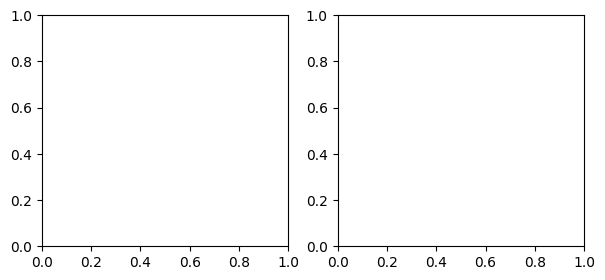

In [25]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))

<BarContainer object of 5 artists>

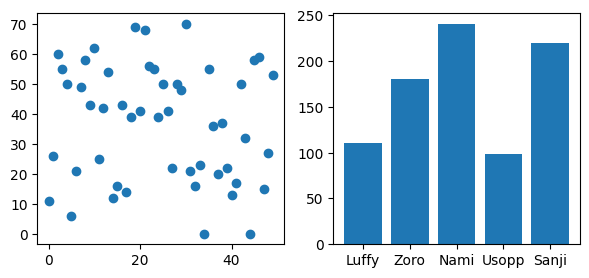

In [26]:
# add data to each
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
ax1.scatter(x1, y1)
ax2.bar(x2, y2)

## subplot_mosaic
more flexible layouts - plots can span rows/cols

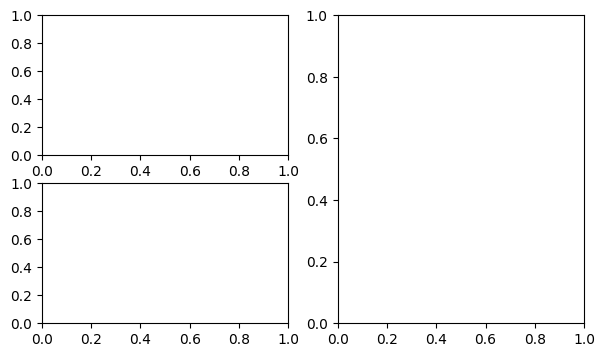

In [27]:
# ax3 spans both rows on right side
fig, axes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                               figsize=(7, 4))

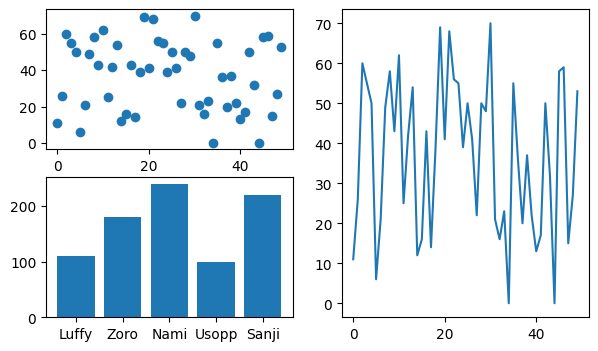

In [28]:
# reference by name
fig, axes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                               figsize=(7, 4))
axes["ax1"].scatter(x1, y1)
axes["ax2"].bar(x2, y2)
axes["ax3"].plot(x1, y1)

Text(0.5, 0, 'Third Label')

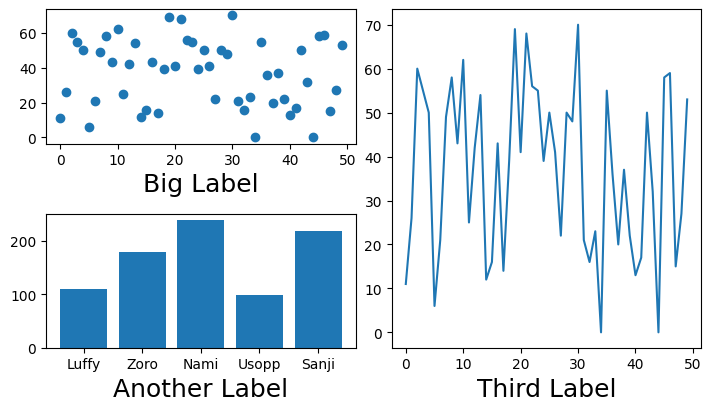

In [29]:
# constrained layout - prevents label overlap
fig, axes = plt.subplot_mosaic([['ax1', 'ax3'],
                                ['ax2', 'ax3']],
                               figsize=(7, 4),
                               layout="constrained")
axes["ax1"].scatter(x1, y1)
axes["ax2"].bar(x2, y2)
axes["ax3"].plot(x1, y1)
axes["ax1"].set_xlabel('Big Label', fontsize=18)
axes["ax2"].set_xlabel('Another Label', fontsize=18)
axes["ax3"].set_xlabel('Third Label', fontsize=18)

## multiple plot types on same axes
just call multiple methods

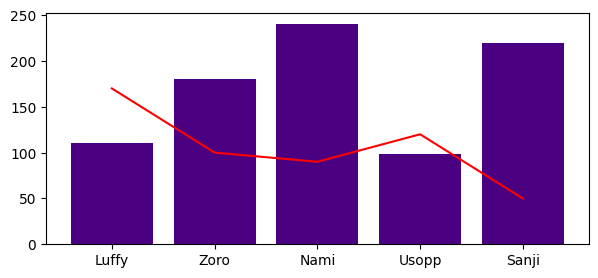

In [30]:
# bar + line overlay
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(x, y1, color="indigo")
ax.plot(x, y2, color="red")

## error bars
show uncertainty/variability

<ErrorbarContainer object of 3 artists>

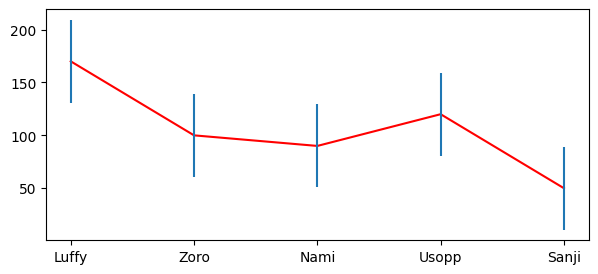

In [31]:
y2_sd = np.std(y2)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color="red")

# fmt="none" = don't draw extra markers, just error bars
ax.errorbar(x, y2, yerr=y2_sd, fmt="none")

<ErrorbarContainer object of 3 artists>

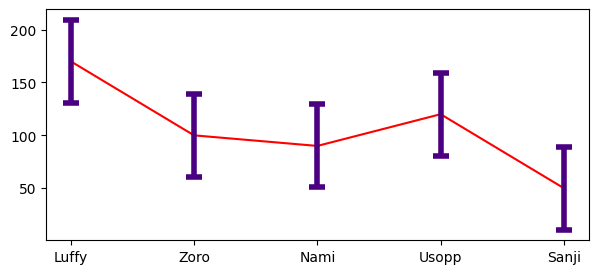

In [32]:
# customize error bar appearance
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color="red")

ax.errorbar(x, y2, yerr=y2_sd, fmt="none",
            ecolor="indigo",
            elinewidth=4,
            capsize=6,
            capthick=4)

<ErrorbarContainer object of 3 artists>

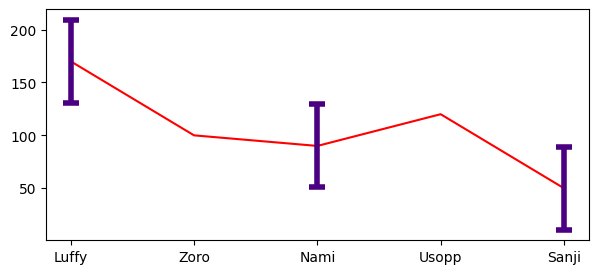

In [33]:
# errorevery - skip some points
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color="red")

ax.errorbar(x, y2, yerr=y2_sd, fmt="none",
            ecolor="indigo",
            elinewidth=4,
            capsize=6,
            capthick=4,
            errorevery=2)  # every 2nd point

## adding images to plots

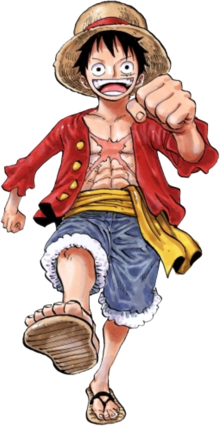

In [34]:
response = requests.get('https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png',
                        headers={'User-Agent': 'Mozilla/5.0'})
image_file = BytesIO(response.content)
image = Image.open(image_file)
image

(np.float64(-0.5), np.float64(219.5), np.float64(425.5), np.float64(-0.5))

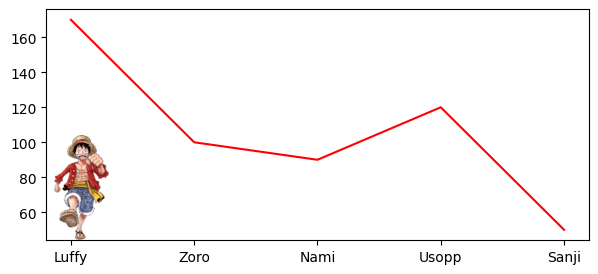

In [35]:
# add image to plot using add_axes
# [x, y, width, height] as fraction of figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color="red")

ax_image = fig.add_axes([0.1, 0.11, 0.15, 0.35])
ax_image.imshow(image)
ax_image.axis('off')  # hide axes on image

## saving figures
```python
# example - adjust path as needed
plt.savefig('myfigure.png', dpi=300)
```